In [34]:
## load packages
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import pandas as pd
from adjustText import adjust_text
from scipy import interpolate 
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick


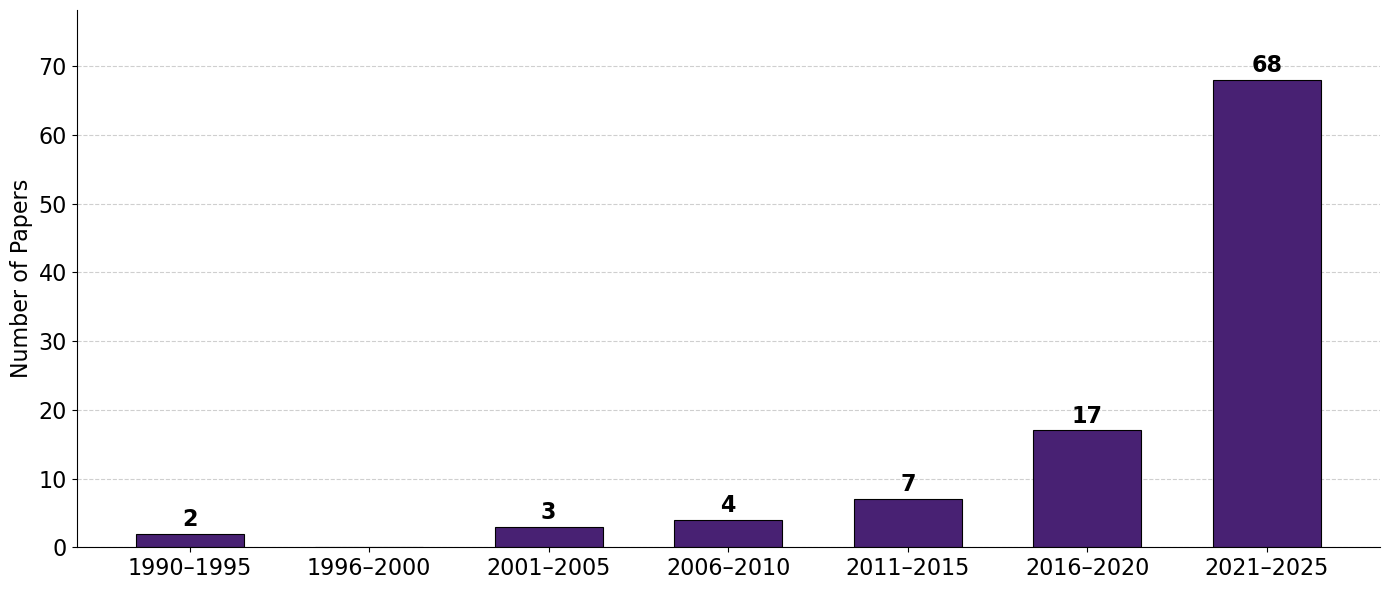

In [10]:
## Figure 1 ## 
## declare bins, summarized from the excel spreadsheet 
bins = [
    '1990–1995',
    '1996–2000',
    '2001–2005',
    '2006–2010',
    '2011–2015',
    '2016–2020',
    '2021–2025',
]
counts = [
    2,   
    0,  
    3,  
    4,   
    7,   
    17,  
    68
]
### figure 1 
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(bins, counts, color='#482173', edgecolor='black', linewidth=0.8, width=0.6)
## to add the count 
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            str(count),
            ha='center', va='bottom',
            fontsize=16, fontweight='bold'
        )
ax.set_ylabel('Number of Papers', fontsize=16)
ax.set_ylim(0, max(counts) * 1.15)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('ml_snow_papers_by_period.png', dpi=300, bbox_inches='tight')
plt.show()

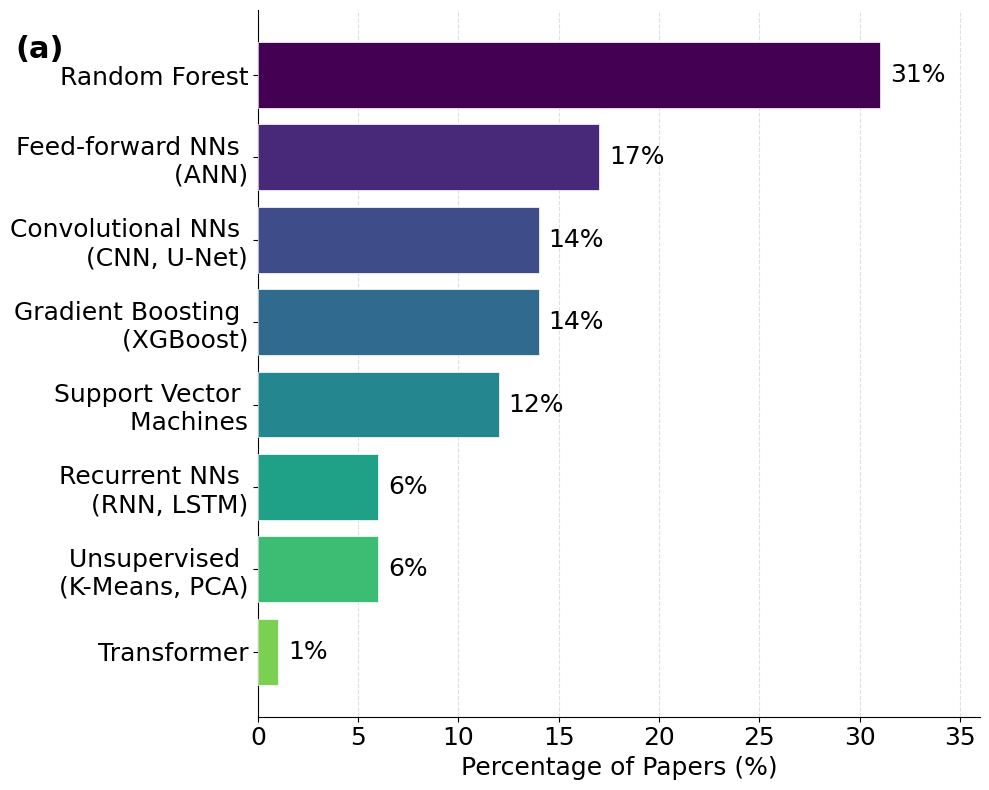

In [21]:
#### Figure 2A ####
### this all pulled from the excel sheet ### 
percentages = {
    'Random Forest': 31,
    'Feed-forward NNs \n (ANN)': 17,
    'Convolutional NNs \n (CNN, U-Net)': 14,
    'Gradient Boosting \n (XGBoost)': 14,
    'Support Vector \n Machines': 12,
    'Recurrent NNs \n (RNN, LSTM)': 6,
    'Unsupervised \n (K-Means, PCA)': 6,
    'Transformer': 1,
}

# sort descending by count
sorted_models = sorted(percentages, key=percentages.get, reverse=True)
sorted_values = [percentages[m] for m in sorted_models]

# Generate a color gradient for the bars
colors = cm.viridis(np.linspace(0, 0.8, len(sorted_models)))

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')

y = np.arange(len(sorted_models))

bars = ax.barh(
    y, sorted_values,
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

# Percentage labels at end of each bar
for i, pct in enumerate(sorted_values):
    ax.text(pct + 0.5, i, f"{pct:.0f}%",
            va='center', ha='left', fontsize=18)

ax.set_yticks(y)
ax.set_yticklabels(sorted_models, fontsize=18)
ax.invert_yaxis()
ax.set_xlim(0, max(sorted_values) + 5)
ax.set_xlabel('Percentage of Papers (%)', fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

fig.text(0.02, 0.95, '(a)', fontsize=22, fontweight='bold', va='top', ha='left')
plt.tight_layout()
plt.savefig('figure_model_percentages.png', dpi=300, bbox_inches='tight')
plt.show()

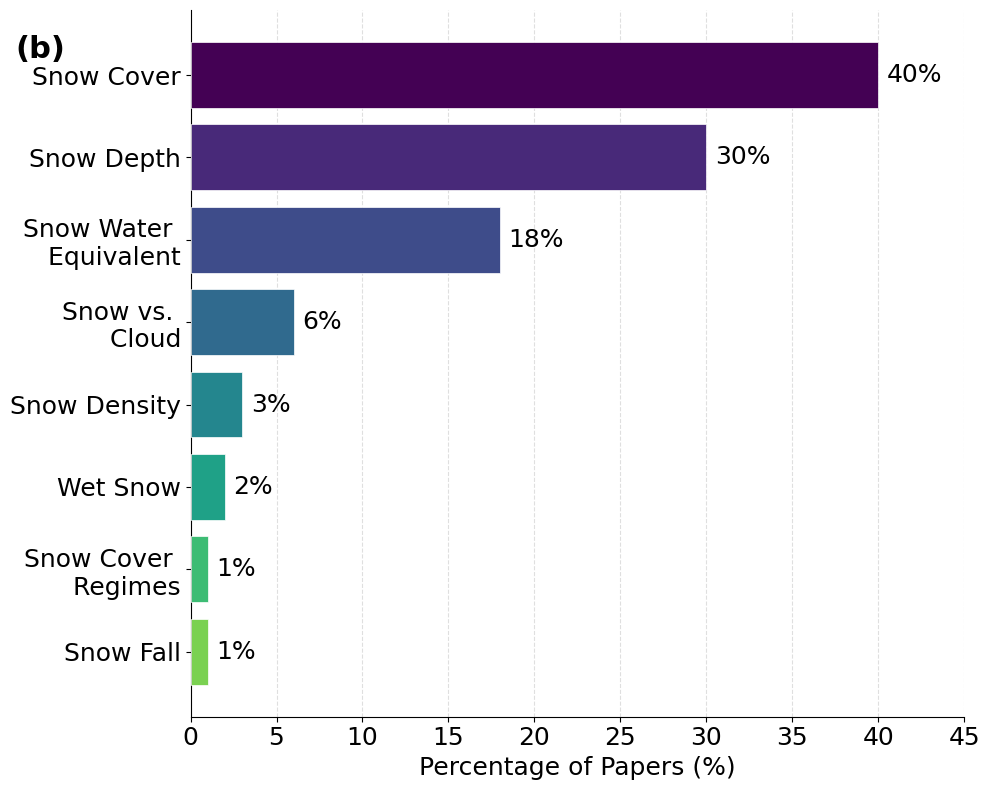

In [29]:
## also pulled from excel spreadsheet ## 

#### Figure 2B ####
percentages = {
    'Snow Cover': 40,
    'Snow Depth': 30,
    'Snow Water \n Equivalent': 18,
    'Snow vs. \n Cloud': 6,
    'Snow Density': 3,
    'Wet Snow': 2,
    'Snow Cover \n Regimes': 1,
    'Snow Fall': 1,
}
## sort and calc percentages 
sorted_props = sorted(percentages, key=percentages.get, reverse=True)
sorted_counts = [percentages[p] for p in sorted_props]

## colorbar 
colors = cm.viridis(np.linspace(0, 0.8, len(sorted_props)))

## plot 
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')

y = np.arange(len(sorted_counts))
bars = ax.barh(
    y, sorted_counts,
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)
## label bar 
for i, pct in enumerate(sorted_counts):
    ax.text(pct + 0.5, i, f"{pct:.0f}%",
            va='center', ha='left', fontsize=18)
ax.set_yticks(y)
ax.set_yticklabels(sorted_props, fontsize=18)
ax.invert_yaxis()
ax.set_xlim(0, max(sorted_counts) + 5)
ax.set_xlabel('Percentage of Papers (%)', fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
fig.text(0.02, 0.95, '(b)', fontsize=22, fontweight='bold', va='top', ha='left')
ax.set_axisbelow(True)
plt.tight_layout()
# plt.savefig('figure_snow_property_percentages_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

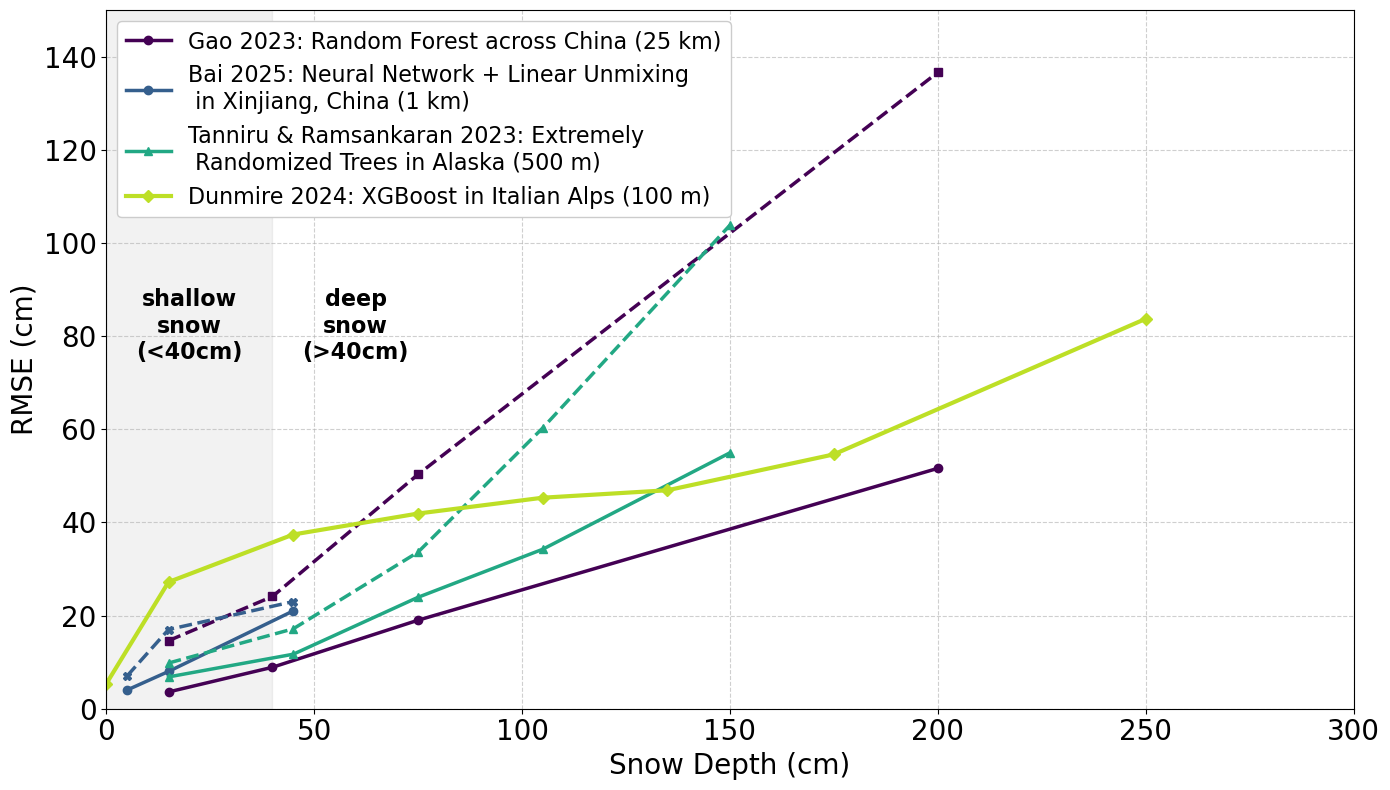

In [6]:
### Figure 3 ### 

'''
Plot the following four studies: 
Gao 2023 (Table 4 in paper)
Bai 2025
Tanniru 2023 
Dunmire 2024

# baseline (e.g., ERA5 or AMSR2) = solid
# ml approach = dashed 

'''

### give each study it's own color 
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 0.9, 4))
c_gao, c_bai, c_tan, c_dun = colors

### gai 
## this is spulled from 
gao_x = [15, 40, 75, 200]
gao_rf_ml = [3.6, 8.9, 19.0, 51.6]
gao_amsr2_pmw = [14.6, 24.1, 50.3, 136.6]
plt.plot(gao_x, gao_amsr2_pmw, marker='s', linestyle='--', linewidth=2.5, color=c_gao, 
         label='')
plt.plot(gao_x, gao_rf_ml, marker='o', linestyle='-', linewidth=2.5, color=c_gao, 
         label='Gao 2023: Random Forest across China (25 km)')

### bai 
## this is pulled from 
bai_x_era5 = [5, 15, 45] 
bai_x_amsr2 = [5, 15, 45]
bai_rmse_era5 = [4, 8, 21] 
bai_rmse_amsr2 = [7, 17, 23] # Fixed typo in variable name
plt.plot(bai_x_amsr2, bai_rmse_amsr2, marker='X', linestyle='--', linewidth=2.5, color=c_bai, 
         label='')
plt.plot(bai_x_era5, bai_rmse_era5, marker='o', linestyle='-', linewidth=2.5, color=c_bai, 
         label='Bai 2025: Neural Network + Linear Unmixing \n in Xinjiang, China (1 km)')

## tanniru paper
## validated with AMSR2
## they had 6 different zones for different regions of Alaska, so 6 different models, so we will average for now
tan_x = [15, 45, 75, 105, 150] 
## this is all pulled from table VII
## We disregard >0 (because that's all snow depth values) and just look at 0-30 cm for this analysis. 
# ERT (Model) 
z1_ert_all = [7.80, 8.62, 9.02, 9.29, 31.77] ## north slope
z2_ert_all = [3.24] ## west coast 
z3_ert_all = [7.89, 12.31, 29.96, 44.45]  ## central interior
z4_ert_all = [6.00, 9.63, 23.56] ## northeast interior
z5_ert_all = [6.67, 10.13, 23.38, 37.42, 62.10] ## southeast interior
z6_ert_all = [9.365, 17.82, 33.68, 45.79, 70.93]  ## cook inlet bristol 

# AMSR2 (Baseline) 
## same zones as above 
z1_amrs2 = [9.34, 21.70, 42.77, 48.21, 76.13]  
z2_amsr2 = [6.95]  
z3_amsr2 = [15.36, 16.22, 29.11, 54.47] 
z4_amsr2 = [6.74, 9.83, 22.77]  
z5_amsr2 = [10.29, 12.57, 22.19, 55.80, 94.53] 
z6_amsr2 = [10.14, 25.45, 51.21, 82.62, 140.72] 

# Helper to average the varying-length lists into one single line
def average_zones(zones, max_len=5):
    padded = [z + [np.nan]*(max_len - len(z)) for z in zones]
    return np.nanmean(padded, axis=0)

tan_rmse_ert_mean = average_zones([z1_ert_all, z2_ert_all, z3_ert_all, z4_ert_all, z5_ert_all, z6_ert_all])
tan_rmse_amsr2_mean = average_zones([z1_amrs2, z2_amsr2, z3_amsr2, z4_amsr2, z5_amsr2, z6_amsr2])
plt.plot(tan_x, tan_rmse_amsr2_mean, marker='^', linestyle='--', linewidth=2.5, color=c_tan, 
         label='')
plt.plot(tan_x, tan_rmse_ert_mean, marker='^', linestyle='-', linewidth=2.5, color=c_tan, 
         label='Tanniru & Ramsankaran 2023: Extremely \n Randomized Trees in Alaska (500 m)')


## 
dun_x = [0, 15, 45, 75, 105, 135, 175, 250] # 400, 500]
dun_rmse = [5.31, 27.2, 37.4, 41.9, 45.3, 46.9, 54.6, 83.7] #177.7, 362.1]
plt.plot(dun_x, dun_rmse, marker='D', linestyle='-', linewidth=3, color=c_dun, 
         label='Dunmire 2024: XGBoost in Italian Alps (100 m)')

plt.title('', fontsize=18, fontweight='bold')
plt.xlabel('Snow Depth (cm)', fontsize=20, )
plt.ylabel('RMSE (cm)', fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 300)
plt.ylim(0, 150)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.axvspan(0, 40, color='gray', alpha=0.1)
plt.text(20, 75, 'shallow\nsnow\n(<40cm)', color='black', fontweight='bold', ha='center', fontsize=16)
plt.text(60, 75, 'deep\nsnow\n(>40cm)', color='black', fontweight='bold', ha='center', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=16, framealpha=1)

plt.tight_layout()
plt.show()

In [39]:
## Figure 4A and B ## 

#### updated as of Sept 8 2026 ### 
input_data = {
    'Passive Microwave': { #\n(SSM/I, AMSR-E, AMSR2)
        'Snow Cover': 2,  'SWE': 11, 'Snow Depth': 17, 'Other': 4},
    'Optical': { #\n (MODIS, Landsat, Sentinel-2, AVHRR)
        'Snow Cover': 28, 'SWE': 3, 'Snow Depth': 3, 'Other': 8},
    'Topography': { #DEM/Elevation\n(Topography, Slope, Aspect)
        'Snow Cover': 10,  'SWE': 2, 'Snow Depth': 14, 'Other': 1},
    'Reanalysis': { #\n(ERA5/MERRA/GlobSnow, Met Data)
        'Snow Cover': 1,  'SWE': 2, 'Snow Depth': 4, 'Other': 1},
    'C-Band SAR': { #\n(Sentinel-1, RadarSat)
        'Snow Cover': 4,  'SWE': 0, 'Snow Depth': 8, 'Other': 2},
    'Land Cover': { #\n(Forest fraction, Surface type)
        'Snow Cover': 5,  'SWE': 3, 'Snow Depth': 12, 'Other': 1},
    'High-Res. Optical': { #\n(PlanetScope, Worldview, Pleiades, Gaofen)
        'Snow Cover': 3,  'SWE': 1, 'Snow Depth': 2, 'Other': 0},
    'X-Band SAR': { #\n(Cosmo-SkyMed)
        'Snow Cover': 0,  'SWE': 1, 'Snow Depth': 0, 'Other': 0},
    'L-Band SAR': { #/ Passive\n(SMAP)
        'Snow Cover': 0,  'SWE': 1, 'Snow Depth': 0, 'Other': 0},
    'Weather Station Data': { #\n(In situ, Ground, Snow pillows)
        'Snow Cover': 1,  'SWE': 1, 'Snow Depth': 3, 'Other': 1},
}

val_data = {
    'Weather Stations': { # & In Situ\n(Stations, Ground obs, SNOTEL)
        'Snow Cover': 6,  'SWE': 7, 'Snow Depth': 19, 'Other': 3},
        
    'Optical Imagery': { #\n(Landsat, MODIS, Sentinel-2)
        'Snow Cover': 18,  'SWE': 0, 'Snow Depth': 1, 'Other': 4},
        
    'Lidar & ASO': { #\n(Airborne Snow Observatory)
        'Snow Cover': 3,  'SWE': 2, 'Snow Depth': 5, 'Other': 0},
        
    'Field Measurements': { #Manual/\n(Snowpits, time-lapse, wetness)
        'Snow Cover': 3,  'SWE': 0, 'Snow Depth': 3, 'Other': 3},
        
    'Reanalysis': { #& Models\n(ERA5, GlobSnow, CROCUS)
        'Snow Cover': 0,  'SWE': 2, 'Snow Depth': 1, 'Other': 3},
        
    'Passive Microwave \n SD Products': { #Products\n(AMSR2, Existing SD products)
        'Snow Cover': 0,  'SWE': 0, 'Snow Depth': 3, 'Other': 0},
        
    'High-Res Optical': { #\n(GF-1, IKONOS, TH-1)
        'Snow Cover': 1,  'SWE': 0, 'Snow Depth': 0, 'Other': 0},
}

# ── SNOW PROPERTY COLOR PALETTE ───────────────────────────────────────────────
PROP_COLORS = {
    'Snow Cover':  '#440154',  # viridis 0.00 (dark purple)
    'SWE':         '#FDE725',  # viridis 0.33 (yellow) 
    'Snow Depth':  '#35B779',  # viridis 0.66 (green)
    'Other':       '#31688E',  # viridis 1.00 (blue)
}
EDGE_COLOR = 'white'
PROPERTIES = ['Snow Cover', 'SWE', 'Snow Depth', 'Other']

def style_ax(ax, title, xlabel):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    ax.tick_params(axis='y', labelsize=18)
    ax.tick_params(axis='x', labelsize=18)
    # Format x-axis as percentage
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    #  ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.xaxis.set_major_locator(mtick.MultipleLocator(10))

def make_legend(ax):
    handles = [mpatches.Patch(color=PROP_COLORS[p], label=p) for p in PROPERTIES]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(0.60, 0.5),
              fontsize=18, title='Snow Property',
              title_fontsize=18, framealpha=0.9)

def make_stacked_bar(data, title, xlabel, filename, figsize=(11, 7), label = '(a)'):
    # Calculate row totals for sorting
    totals = {k: sum(v.values()) for k, v in data.items()}
    sorted_keys = sorted(totals, key=totals.get, reverse=True)
    
    # Calculate the GRAND TOTAL of all data points
    grand_total = sum(totals.values())

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')

    y = np.arange(len(sorted_keys))
    bottoms = np.zeros(len(sorted_keys))

    for prop in PROPERTIES:
        # Convert to percentage of the GRAND TOTAL
        vals = np.array([
            (data[k][prop] / grand_total * 100) if grand_total > 0 else 0 
            for k in sorted_keys
        ], dtype=float)
        
        ax.barh(y, vals, left=bottoms,
                color=PROP_COLORS[prop],
                edgecolor=EDGE_COLOR,
                linewidth=0.5,
                label=prop,
                zorder=3)
        bottoms += vals

    # Add the percentage label at the end of each bar
    for i, k in enumerate(sorted_keys):
        row_percent = (totals[k] / grand_total) * 100
        # Showing the percentage (e.g., 25.4%) and the absolute count (n=X)
        ax.text(row_percent + 0.5, i, f'{row_percent:.0f}%', # (n={totals[k]})
                va='center', ha='left', fontsize=14)

    ax.set_yticks(y)
    ax.set_yticklabels(sorted_keys)
    ax.invert_yaxis()
    
    # Dynamically set x-limit to fit the longest bar + text
    max_percent = 25 #(max(totals.values()) / grand_total) * 100
    ax.set_xlim(0, max_percent + 15)

    style_ax(ax, title, xlabel)
    make_legend(ax)
    fig.text(0.02, 0.95, label, fontsize=22, fontweight='bold', va='top', ha='left')
    plt.tight_layout()
    #plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {filename}")

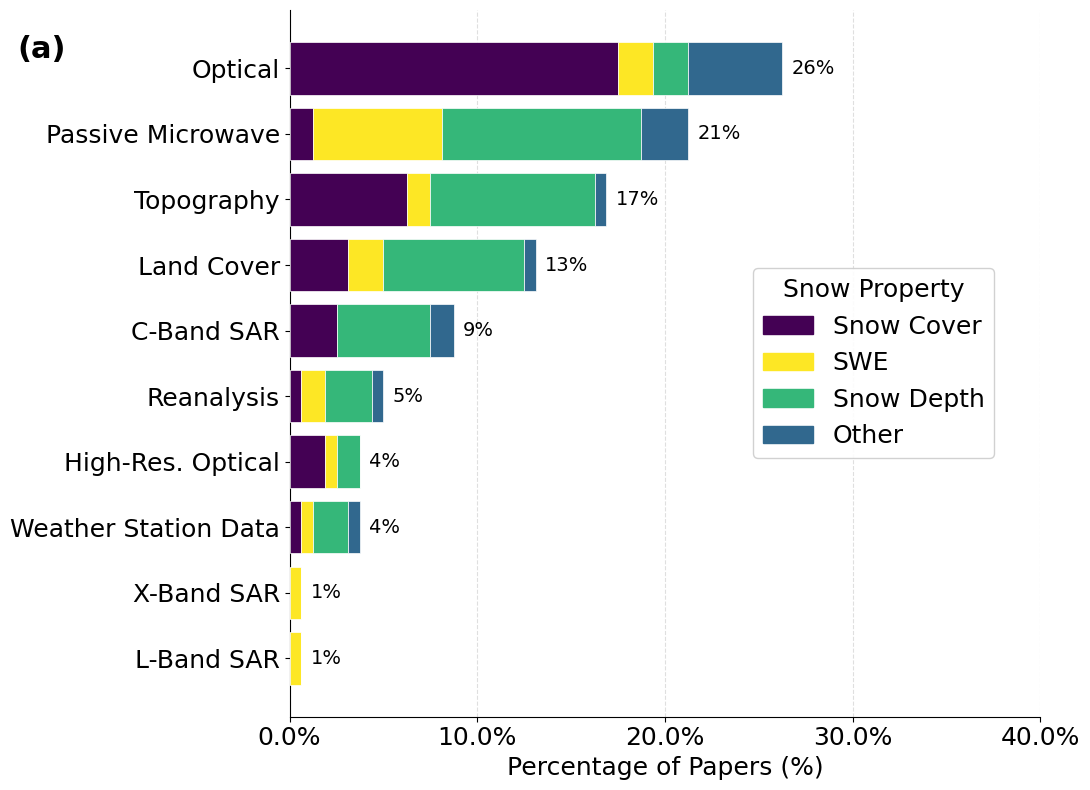

Saved figure_input_sources.png


In [40]:
make_stacked_bar(
    input_data,
    title='Input Data Sources Across Reviewed Papers',
    xlabel='Percentage of Papers (%)',
    filename='figure_input_sources.png',
    figsize=(11, 8), 
    label = '(a)'
)


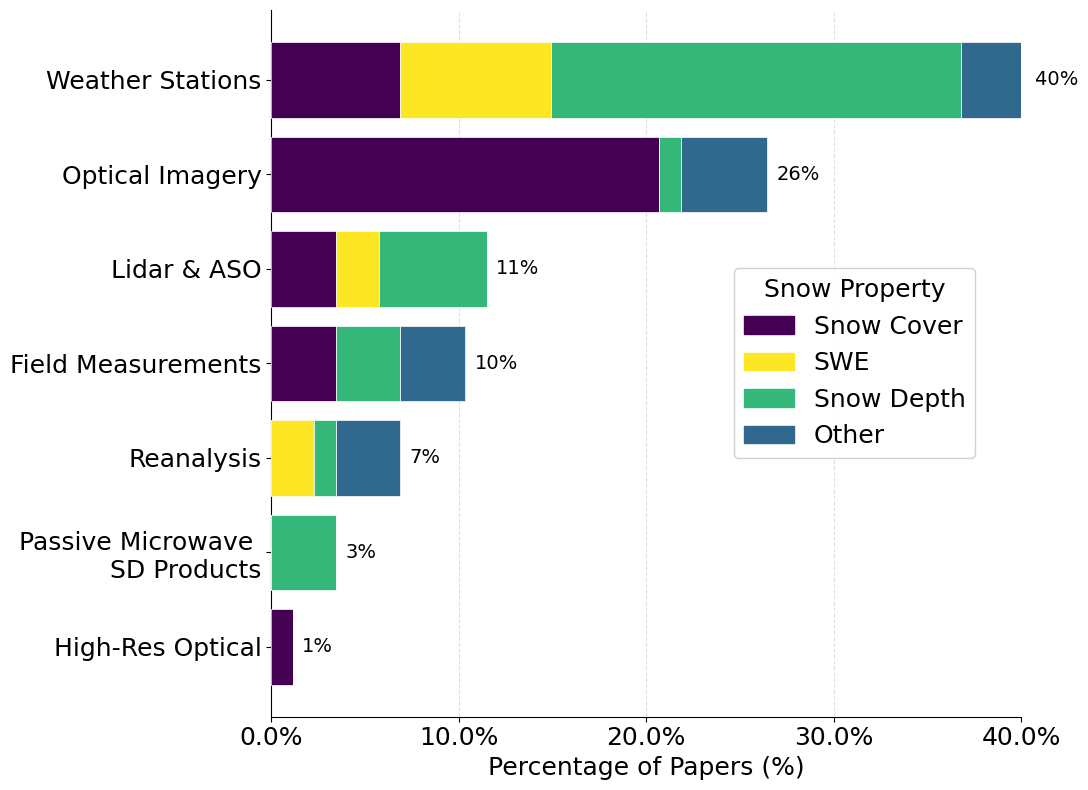

Saved figure_val_sources.png


In [ ]:
make_stacked_bar(
    val_data,
    title='Input Data Sources Across Reviewed Papers',
    xlabel='Percentage of Papers (%)',
    filename='figure_val_sources.png',
    figsize=(11, 8),
    label = '(b)'
)


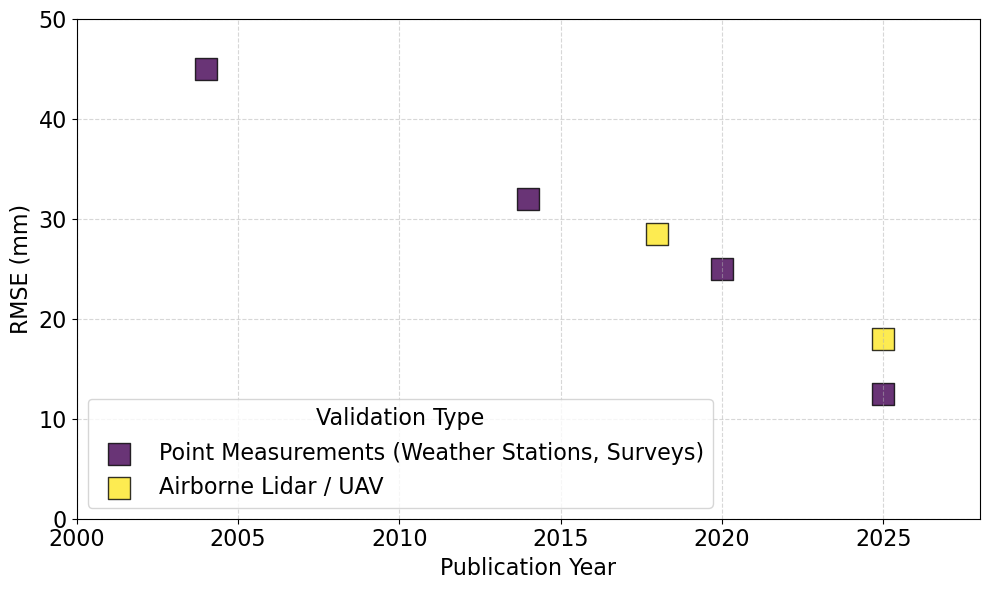

In [38]:
## Figure 5 ## 

data = {
    'Study': [
        'Chang et al. (1992)', 'Tedesco et al. (2004)', 'Tong et al. (2010)', 'Dariane et al. (2014)', 'Bair et al. (2018)',
        'Zaerpour et al. (2020)', 'Yang et al. (2020)', 'Cannistra et al. (2021)', 'Yu et al. (2022)', 'Gao et al. (2023)', 
        'Tanniru & Ramsankaran (2023)', 'Daudt et al. (2023)', 'Dunmire et al. (2024)', 'Yu (2024)', 'Hou (2024)', 
        'Liu (2024)', 'Bai (2025)', 'Brodylo et al. (2025)', 'Wang et al. (2025)', 'Yang et al. (2025)', 'Elyoussfi (2025)'
    ],
    'Year': [
        1992, 2004, 2010, 2014, 2018, 
        2020, 2020, 2021, 2022, 2023, 
        2023, 2023, 2024, 2024, 2024, 
        2024, 2025, 2025, 2025, 2025, 2025
    ],
    'Target': [
        'SD', 'Both', 'SD', 'SWE', 'SWE',
        'SD', 'SWE', 'snow cover', 'SD', 'SD',
        'SD', 'SD', 'SD', 'SD', 'SD',
        'SD', 'SD', 'Both', 'SD', 'SWE', 'SD'
    ],
    'Validation_Source': [
        'In-situ Stations', 'In-situ Stations', 'In-situ Stations', 'SNOTEL / Surveys', 'Airborne Lidar / UAV',
        'In-situ Stations', 'SNOTEL / Surveys', 'SNOTEL / Surveys', 'SNOTEL / Surveys', 'In-situ Stations',
        'SNOTEL / Surveys', 'Airborne Lidar / UAV', 'Airborne Lidar / UAV', 'Airborne Lidar / UAV', 'In-situ Stations',
        'In-situ Stations', 'In-situ Stations', 'Airborne Lidar / UAV', 'In-situ Stations', 'SNOTEL / Surveys', 'In-situ Stations'
    ],
    'RMSE_mm': [
        np.nan, 45.0, np.nan, 32.0, 28.5,
        np.nan, 25.0, np.nan, np.nan, np.nan, #22.0
        np.nan, np.nan, np.nan, np.nan, np.nan,
        np.nan, np.nan, 18.0, np.nan, 12.5, np.nan
    ]
}

df = pd.DataFrame(data)

df['Validation_Source'] = df['Validation_Source'].replace({
    'In-situ Stations': 'Point Measurements (Weather Stations, Surveys)',
    'SNOTEL / Surveys': 'Point Measurements (Weather Stations, Surveys)'
})

color_map = {
    'Point Measurements (Weather Stations, Surveys)': '#440154',       # Blue
    'Airborne Lidar / UAV': '#fde725'      # Orange
}

# Keep only SWE data
df_swe = df.dropna(subset=['RMSE_mm']).copy()

# Set up the figure for just ONE plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.set_title('', fontsize=16)
ax.set_xlabel('Publication Year', fontsize=16,)
ax.set_ylabel('RMSE (mm)', fontsize=16,)

# Plot points
for source, color in color_map.items():
    subset = df_swe[df_swe['Validation_Source'] == source]
    if not subset.empty:
        ax.scatter(subset['Year'], subset['RMSE_mm'], 
                   label=source, color=color, s=250, marker='s', alpha=0.8, edgecolor='k')


ax.set_xlim(2000, 2028)
ax.set_ylim(0, 50)
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='both', labelsize=16)

# Legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower left', 
          fontsize=16, title='Validation Type', title_fontsize=16, frameon=True)

plt.tight_layout()
plt.show()